In [2]:
pip install gwaslab 


Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [3]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import gzip

file_path = "./21001_raw.gwas.imputed_v3.both_sexes.tsv.bgz"
with gzip.open(file_path, 'rt') as f:
    df = pd.read_csv(f, sep='\t') 


In [5]:
df.head()


,variant,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,pval
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342


In [6]:
df['CHR'] = df['variant'].str.split(':').str[0]
df['POS'] = df['variant'].str.split(':').str[1]


In [7]:
df.shape

(13791467, 13)

In [8]:
df=df.rename(columns={'variant':'SNPID', 'pval':'P'})
df.head()


,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786,1,15791
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902,1,69487
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778,1,69569
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997,1,139853
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342,1,692794


In [9]:
df.head()

,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786,1,15791
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902,1,69487
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778,1,69569
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997,1,139853
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342,1,692794


In [10]:
df.head()

,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786,1,15791
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902,1,69487
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778,1,69569
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997,1,139853
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342,1,692794


In [11]:

minor_df=df[df['minor_AF'] > 0.05]
minor_df = minor_df[~minor_df['SNPID'].str.startswith('X:')]
minor_df.head()


,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS
4,1:692794:CA:C,C,0.110590,False,359983,79621.1,2179000.0,-0.016436,0.019585,-0.839228,0.401342,1,692794
5,1:693731:A:G,G,0.115767,False,359983,83348.0,2281760.0,-0.004255,0.018507,-0.229918,0.818155,1,693731
6,1:707522:G:C,C,0.097255,False,359983,70020.6,1916410.0,-0.010428,0.020804,-0.501258,0.616190,1,707522
9,1:730087:T:C,C,0.056424,False,359983,40623.1,1110650.0,-0.047388,0.025783,-1.837930,0.066074,1,730087
10,1:731718:T:C,C,0.121670,False,359983,87598.4,2397990.0,-0.005842,0.017552,-0.332853,0.739246,1,731718


In [12]:
import gwaslab as gl
sumstats=gl.Sumstats(minor_df, snpid='SNPID', pos="POS"  ,fmt='plink')
sumstats.data

2025/02/02 22:07:20 GWASLab v3.5.5 https://cloufield.github.io/gwaslab/
2025/02/02 22:07:20 (C) 2022-2025, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2025/02/02 22:07:20 Start to load format from formatbook....
2025/02/02 22:07:20  -plink format meta info:
2025/02/02 22:07:20   - format_name  : .assoc, .assoc.fisher, .assoc.linear, .assoc.logistic, .assoc.dosage
2025/02/02 22:07:20   - format_source  : https://www.cog-genomics.org/plink/1.9/
2025/02/02 22:07:20   - format_version  : Stable (beta 6.26, 2 Apr)
2025/02/02 22:07:20   - format_citation  : Purcell, S., Neale, B., Todd-Brown, K., Thomas, L., Ferreira, M. A., Bender, D., ... & Sham, P. C. (2007). PLINK: a tool set for whole-genome association and population-based linkage analyses. The American journal of human genetics, 81(3), 559-575.
2025/02/02 22:07:20  -plink to gwaslab format dictionary:
2025/02/02 22:07:20   - plink keys: SNP,CHR,BP,A2,A1,BETA,OR,SE,P,INFO,STAT,CHISQ,NMISS
2025/02/02 22:07:20   - gwaslab 

2025/02/02 22:07:22  -Reading columns          : SNPID,CHR,POS,P
2025/02/02 22:07:22  -Renaming columns to      : SNPID,CHR,POS,P
2025/02/02 22:07:22  -Current Dataframe shape : 6746855  x  4
2025/02/02 22:07:23  -Initiating a status column: STATUS ...
2025/02/02 22:07:23  #WARNING! Version of genomic coordinates is unknown...
2025/02/02 22:07:24 Start to reorder the columns...v3.5.5
2025/02/02 22:07:24  -Current Dataframe shape : 6746855 x 5 ; Memory usage: 311.01 MB
2025/02/02 22:07:24  -Reordering columns to    : SNPID,CHR,POS,P,STATUS
2025/02/02 22:07:24 Finished reordering the columns.
2025/02/02 22:07:24  -Trying to convert datatype for POS: object -> int64...int64
2025/02/02 22:07:25  -Column  : SNPID  CHR   POS   P       STATUS  
2025/02/02 22:07:25  -DType   : object Int64 int64 float64 category
2025/02/02 22:07:25  -Verified: T      T     T     T       T       
2025/02/02 22:07:25  -Current Dataframe memory usage: 311.01 MB
2025/02/02 22:07:25 Finished loading data successful

,SNPID,CHR,POS,P,STATUS
4,1:692794:CA:C,1,692794,0.401342,9999999
5,1:693731:A:G,1,693731,0.818155,9999999
6,1:707522:G:C,1,707522,0.616190,9999999
9,1:730087:T:C,1,730087,0.066074,9999999
10,1:731718:T:C,1,731718,0.739246,9999999
...,...,...,...,...,...
13364298,22:51229717:A:T,22,51229717,0.191730,9999999
13364299,22:51229805:T:C,22,51229805,0.920869,9999999
13364300,22:51231220:A:G,22,51231220,0.750181,9999999
13364301,22:51237063:T:C,22,51237063,0.105807,9999999


In [13]:
sumstats.get_lead(sig_level=5e-8)

2025/02/02 22:07:25 Start to extract lead variants...v3.5.5
2025/02/02 22:07:25  -Current Dataframe shape : 6746855 x 5 ; Memory usage: 311.01 MB
2025/02/02 22:07:25  -Processing 6746855 variants...
2025/02/02 22:07:25  -Significance threshold : 5e-08
2025/02/02 22:07:25  -Sliding window size: 500  kb
2025/02/02 22:07:27  -Using P for extracting lead variants...
2025/02/02 22:07:27  -Found 49937 significant variants in total...
2025/02/02 22:07:29  -Identified 440 lead variants!
2025/02/02 22:07:29 Finished extracting lead variants.


,SNPID,CHR,POS,P,STATUS
4481,1:1590521:G:A,1,1590521,2.570000e-15,9999999
10167,1:2723214:C:A,1,2723214,3.299290e-11,9999999
33413,1:6669970:C:G,1,6669970,3.770110e-08,9999999
94800,1:19964098:C:T,1,19964098,4.894670e-08,9999999
112330,1:23422623:GA:G,1,23422623,1.658770e-09,9999999
...,...,...,...,...,...
13150460,21:42653237:A:G,21,42653237,3.556230e-08,9999999
13158951,21:43966144:A:G,21,43966144,3.000680e-08,9999999
13174548,21:46488959:G:A,21,46488959,2.279990e-14,9999999
13301879,22:40677499:A:AT,22,40677499,3.056980e-14,9999999


In [14]:
# sumstats.plot_mqq(skip=2,anno=True)

In [15]:
# sumstats.plot_mqq(mode="r", anno=True, region=(1, 110232801, 151018861), region_grid=True, build='hg19')



In [16]:
# gl.download_ref("1kg_eas_hg19")



In [17]:
variant_position = 1421085
start_pos= variant_position- 500000
end_pos= variant_position +500000

In [18]:
locus = sumstats.filter_value(f'CHR==16 & POS>{start_pos} & POS<{end_pos}')

2025/02/02 22:07:29 Start filtering values by condition: CHR==16 & POS>921085 & POS<1921085
2025/02/02 22:07:29  -Removing 6743039 variants not meeting the conditions: CHR==16 & POS>921085 & POS<1921085
2025/02/02 22:07:29 Finished filtering values.


In [19]:
df = locus.data.copy()
locus.data["SNPID"].to_csv("../notebooks/sig_locus.snplist.txt",sep="\t",index=None,header=None)

In [23]:


locus.data[["CHR","POS", "POS"]].to_csv("../notebooks/filtered_snplist.txt", sep="\t", index=False, header=False)


In [32]:
plink --vcf chr16_eur/ALL.chr16.vcf.gz \
      --keep chr16_eur/eur_samples.txt \
      --make-bed \
      --out chr16_eur/chr16_eur \
      --set-missing-var-ids @:#:\$r:\$a


PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../notebooks/sig_locus_mt.log.
Options in effect:
  --bfile ../notebooks/chr16_eur/chr16_eur
  --extract ../notebooks/sig_locus.snplist
  --keep-allele-order
  --out ../notebooks/sig_locus_mt
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.
2697949 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../notebooks/sig_locus_mt.nosex .
Error: No variants remaining after --extract.
PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../notebooks/sig_locus_mt_r2.log.
Options in effect:
  --bfile ../notebooks/chr16_eur/chr16_eur
  --extract ../notebooks/sig_locus.snplist
  --keep-allele-order
  --out ../notebo

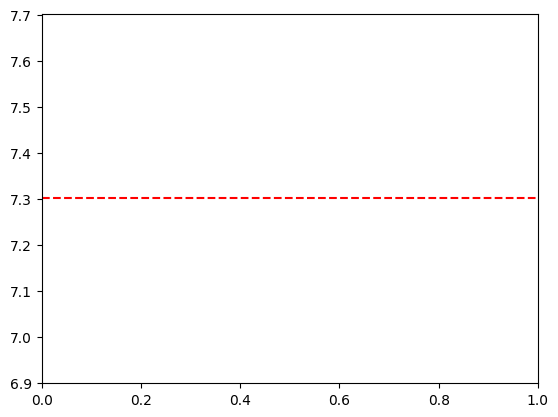

In [21]:
plt.axhline(y=-np.log10(5e-8), color='red', linestyle='--')
plt.show()

In [22]:
minor_df.plt(skip=2,anno=True)

AttributeError: 'DataFrame' object has no attribute 'plt'

In [95]:
sumstatus.plot_mqq(mode="r", anno=True, region=(2,54513738,56513738), region_grid=True, build='hg19')

UnboundLocalError: local variable 'snpid' referenced before assignment

In [10]:
# gl.download_ref("1kg_eas_hg19")

2025/01/21 22:15:42 Start to download  1kg_eas_hg19  ...
2025/01/21 22:15:42  -Downloading to: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2025/01/21 22:15:42  -File /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz exists.
2025/01/21 22:15:49  -File path: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2025/01/21 22:15:49  -MD5 check: c8c97434843c0da3113fc06879ead472
2025/01/21 22:15:49  -MD5 verified.
2025/01/21 22:15:49  -Updating record in config file...
2025/01/21 22:15:49  -File /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi exists.
2025/01/21 22:15:49  -Updating record in config file...
2025/01/21 22:15:49  -Downloading to: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi
2025/01/21 22:15:49 Downloaded  1kg_eas_hg19  successfully!


2025/01/21 22:15:58 Start to create MQQ plot...v3.5.5:
2025/01/21 22:15:58  -Genomic coordinates version: 19...
2025/01/21 22:15:58  -Genome-wide significance level to plot is set to 5e-08 ...
2025/01/21 22:15:58  -Raw input contains 907921 variants...
2025/01/21 22:15:58  -MQQ plot layout mode is : r
2025/01/21 22:15:58  -Region to plot : chr2:54531536-56731536.
2025/01/21 22:15:58  -Checking chromosome notations in VCF/BCF files...
2025/01/21 22:15:58  -Checking prefix for chromosomes in VCF/BCF files...
2025/01/21 22:15:58  -No prefix for chromosomes in the VCF/BCF files.
2025/01/21 22:15:58  -Extract SNPs in region : chr2:54531536-56731536...
2025/01/21 22:15:58  -Extract SNPs in specified regions: 795
2025/01/21 22:15:58 Finished loading specified columns from the sumstats.
2025/01/21 22:15:58 Start data conversion and sanity check:
2025/01/21 22:15:58  -Removed 0 variants with nan in CHR or POS column ...
2025/01/21 22:15:58  -Removed 0 variants with CHR <=0...
2025/01/21 22:15:5

2025/01/21 22:26:43  -Retrieving index...
2025/01/21 22:26:43  -Ref variants in the region: 71908
2025/01/21 22:26:43  -Matching variants using POS, NEA, EA ...
2025/01/21 22:26:43  -Calculating Rsq...
2025/01/21 22:26:43 Finished loading reference genotype successfully!
2025/01/21 22:26:43  -Creating background plot...
2025/01/21 22:26:43  -Extracting lead variant...
2025/01/21 22:26:44  -Loading gtf files from:default


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


2025/01/21 22:27:21  -plotting gene track..
2025/01/21 22:27:21  -plotting genes: 14..
2025/01/21 22:27:21  -plotting exons: 1044..
2025/01/21 22:27:21  -Finished plotting gene track..


2025/01/21 22:27:22 Finished creating MQQ plot successfully!
2025/01/21 22:27:22 Start to extract variants for annotation...
2025/01/21 22:27:22  -Found 1 significant variants with a sliding window size of 500 kb...
2025/01/21 22:27:22 Finished extracting variants for annotation...
2025/01/21 22:27:22 Start to process figure arts.
2025/01/21 22:27:22  -Processing X labels...
2025/01/21 22:27:22  -Processing Y labels...
2025/01/21 22:27:22  -Processing Y tick lables...
2025/01/21 22:27:22  -Processing Y labels...
2025/01/21 22:27:22  -Processing color bar...
2025/01/21 22:27:22  -Processing lines...
2025/01/21 22:27:22 Finished processing figure arts.
2025/01/21 22:27:22 Start to annotate variants...
2025/01/21 22:27:22  -Annotating using column CHR:POS...
2025/01/21 22:27:22  -Adjusting text positions with repel_force=0.03...
2025/01/21 22:27:22 Finished annotating variants.
2025/01/21 22:27:22 Start to save figure...
2025/01/21 22:27:22  -Skip saving figure!
2025/01/21 22:27:22 Finish

(<Figure size 3000x2000 with 4 Axes>, <gwaslab.g_Log.Log at 0x7244ee19fa30>)

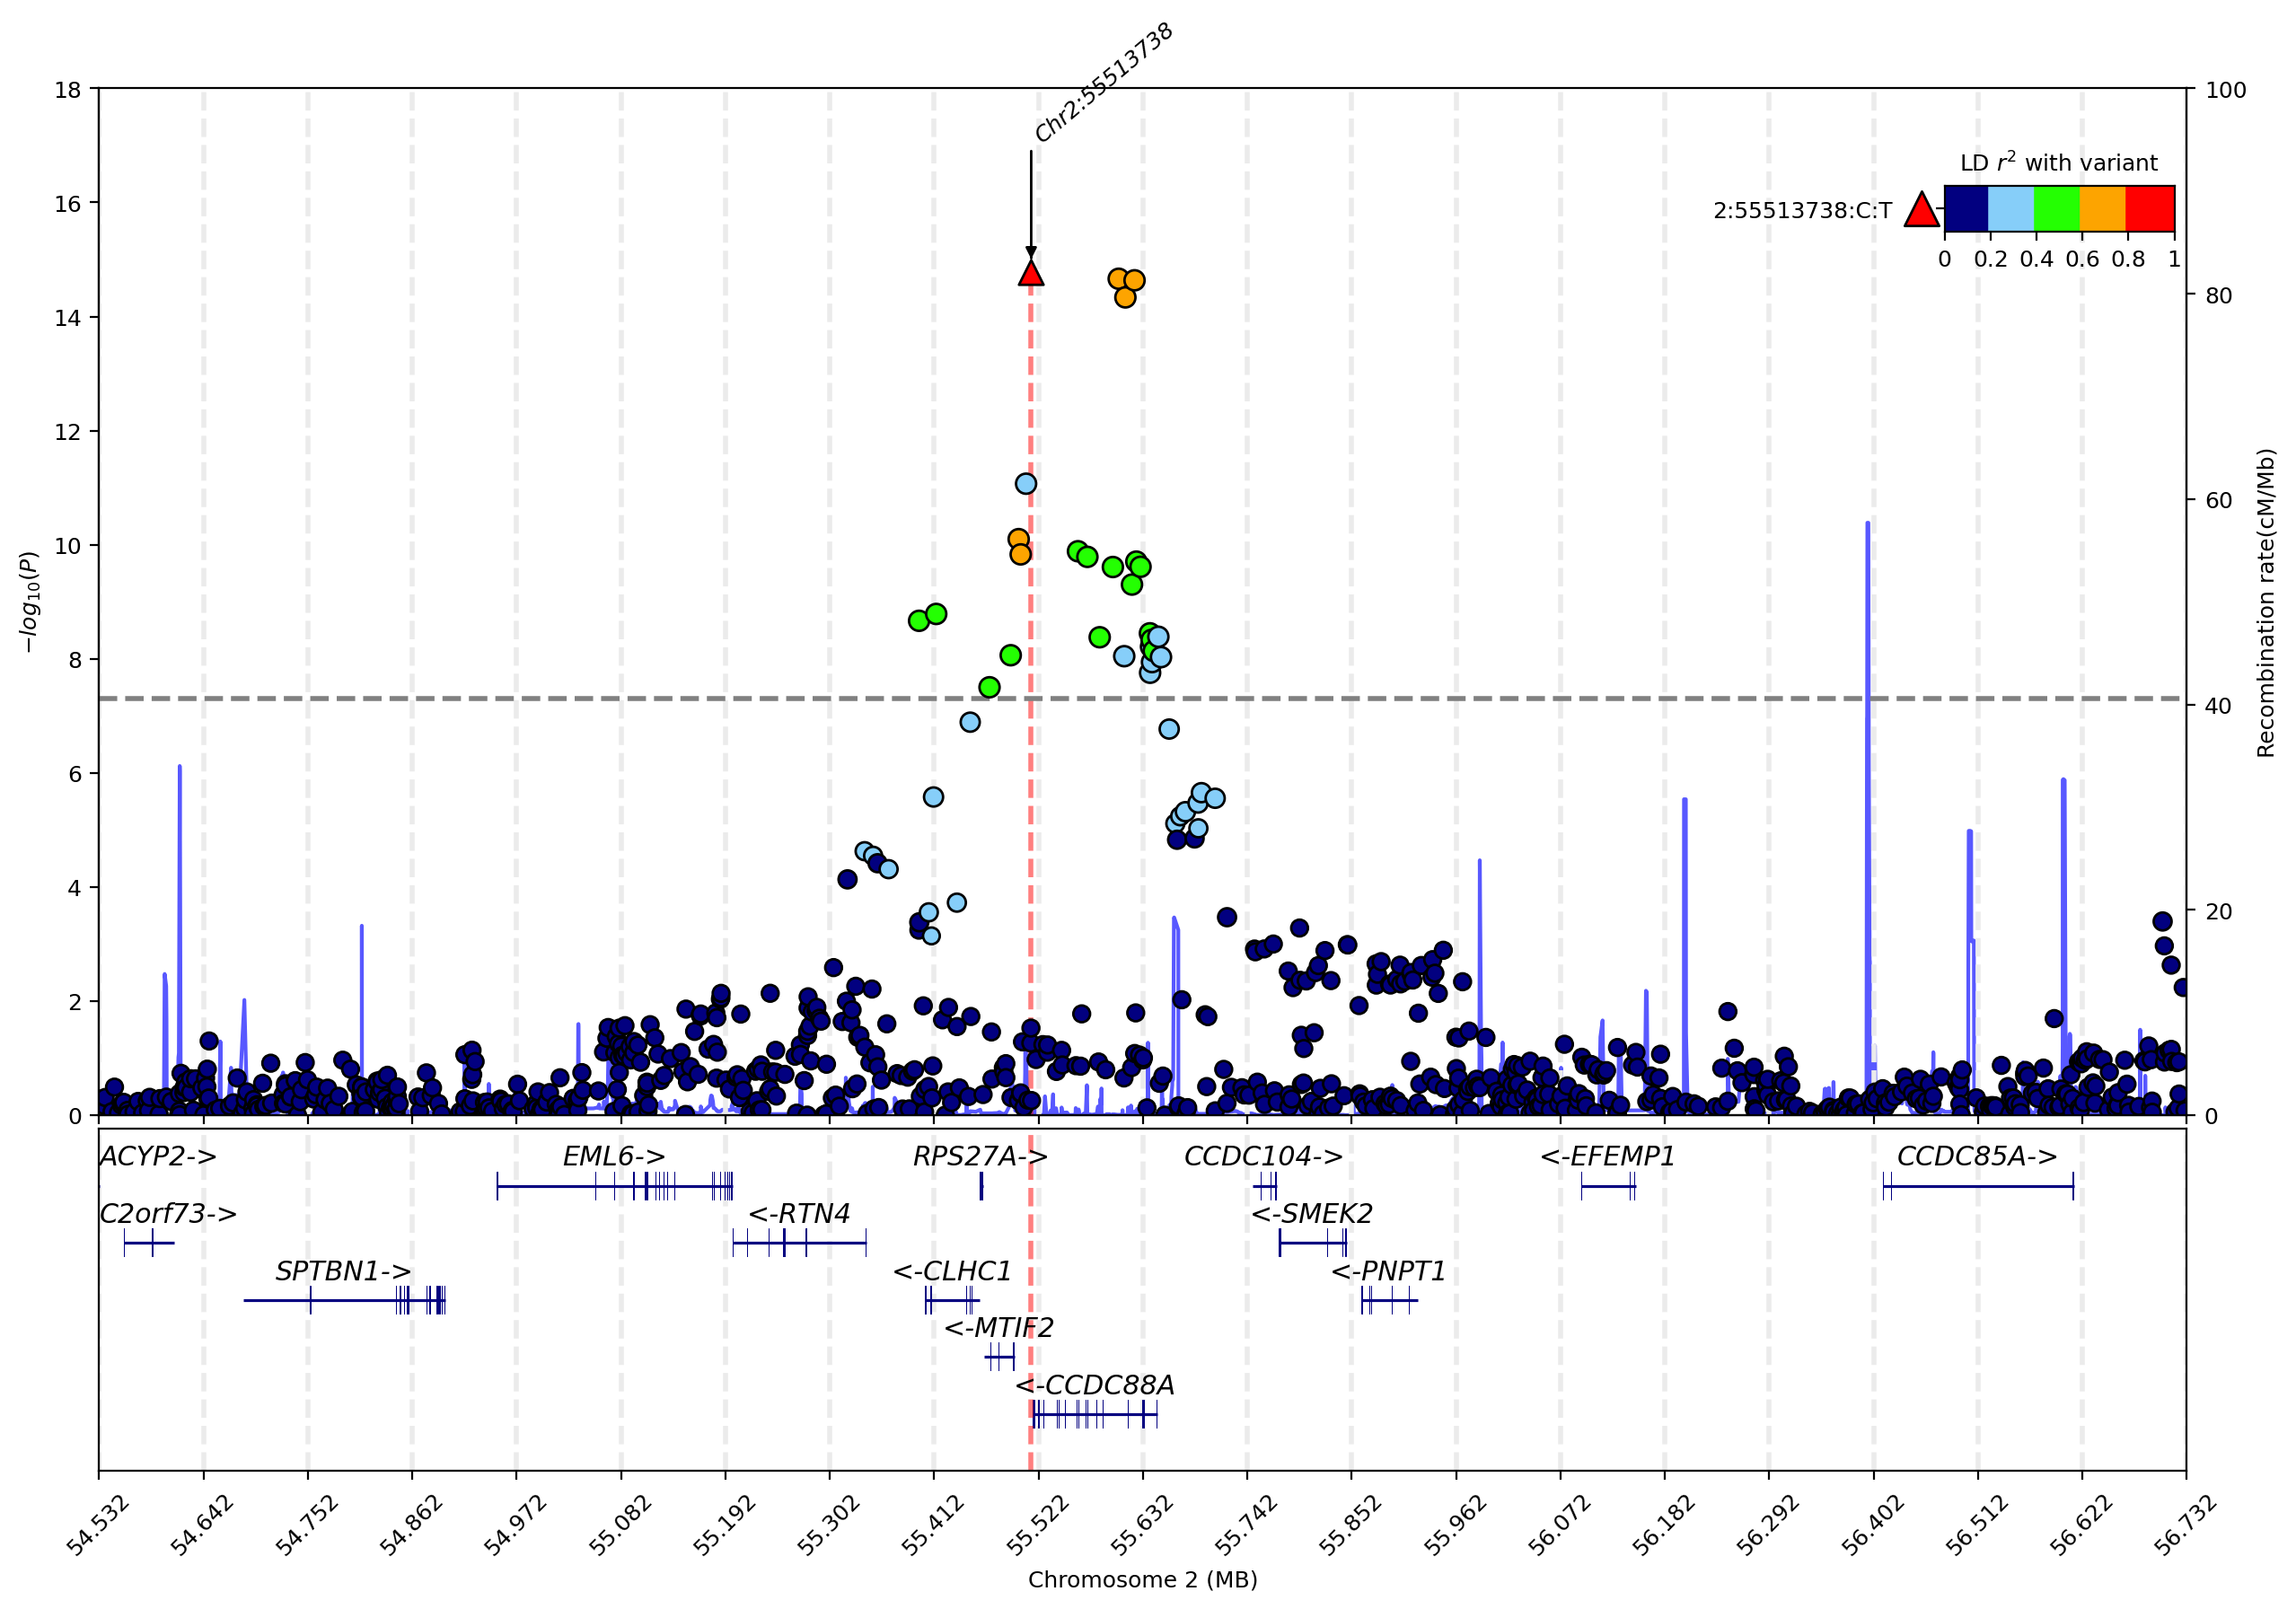

In [11]:
# sumstatus.plot_mqq(mode="r",anno=True,region=(2,54531536,56731536),region_grid=True,vcf_path=gl.get_path("1kg_eas_hg19"),build="19")